# EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

| 変数 | 指標 |
|-----|-----|
| GDP per capita | 豊かさ |
| ジニ係数 | 格差 |
| 女性の労働参加率 | 機会費用 |
| 女性の大学進学率 | 晩婚化 |
| 人口密度 | 都市化 |
| 政府教育支出 | 子育てコスト |

In [2]:
def load_wb(filepath, col_name, year='2018'):
    df = pd.read_csv(filepath, skiprows=4)
    return df[['Country Code', year]].rename(columns={year: col_name})

# fertilityだけCountry Nameも残す
fertility = pd.read_csv('../data/fertility_rate.csv', skiprows=4)
fertility = fertility[['Country Name', 'Country Code', '2018']].rename(columns={'2018': 'fertility_rate'})

gdp = load_wb('../data/gdp_per_capita.csv', 'gdp_per_capita')
gini = load_wb('../data/gini.csv', 'gini')
female_lfp = load_wb('../data/female_lfp.csv', 'female_lfp')
female_edu = load_wb('../data/female_edu.csv', 'female_edu')
pop_density = load_wb('../data/population_density.csv', 'pop_density')
edu_exp = load_wb('../data/education_expenditure.csv', 'edu_expenditure')

In [3]:
# mergeはCountry Codeをキーに順番につなぐ
dfs = [gdp, gini, female_lfp, female_edu, pop_density, edu_exp]

all_df = fertility.copy()
for d in dfs:
    all_df = pd.merge(all_df, d, on='Country Code', how='left')

all_df

,Country Name,Country Code,fertility_rate,gdp_per_capita,gini,female_lfp,female_edu,pop_density,edu_expenditure
0,Aruba,ABW,1.732000,39278.829727,NaN,NaN,NaN,605.044444,4.548764
1,Africa Eastern and Southern,AFE,4.521454,4220.912502,NaN,61.261836,8.017700,44.310939,4.909190
2,Afghanistan,AFG,5.327000,2902.392113,NaN,19.805000,5.020660,56.334482,NaN
3,Africa Western and Central,AFW,4.962572,6016.312217,NaN,65.891715,7.665390,49.989710,3.006575
4,Angola,AGO,5.519000,10000.944377,51.3,73.224000,NaN,25.103999,2.183513
...,...,...,...,...,...,...,...,...,...
261,Kosovo,XKX,1.581000,11188.224463,44.6,NaN,NaN,NaN,NaN
262,"Yemen, Rep.",YEM,4.607000,NaN,NaN,4.987000,NaN,64.558937,NaN
263,South Africa,ZAF,2.270000,14553.561567,NaN,48.518000,26.524965,48.317108,5.644010
264,Zambia,ZMB,4.492000,3646.959665,NaN,52.138000,NaN,24.177846,4.739740


In [4]:
# OECD38カ国に絞る
oecd_codes = ['AUS','AUT','BEL','CAN','CHL','COL','CRI','CZE','DNK','EST',
              'FIN','FRA','DEU','GRC','HUN','ISL','IRL','ISR','ITA','JPN',
              'KOR','LVA','LTU','LUX','MEX','NLD','NZL','NOR','POL','PRT',
              'SVK','SVN','ESP','SWE','CHE','TUR','GBR','USA']

oecd_df = all_df[all_df['Country Code'].isin(oecd_codes)].reset_index(drop=True)

In [5]:
oecd_df.isnull().sum()

Country Name       0
Country Code       0
fertility_rate     0
gdp_per_capita     0
gini               3
female_lfp         0
female_edu         0
pop_density        0
edu_expenditure    1
dtype: int64

In [6]:
# 欠損値を含む行を削除
oecd_df = oecd_df.dropna().reset_index(drop=True)

In [7]:
oecd_df.describe()

,fertility_rate,gdp_per_capita,gini,female_lfp,female_edu,pop_density,edu_expenditure
count,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000,34.000000
mean,1.624632,52857.498989,33.311765,54.226618,82.285510,149.244814,5.039669
std,0.331124,22453.535542,6.463593,6.967996,21.879282,141.588302,1.253923
min,0.977000,17104.131355,24.600000,34.115000,20.617741,3.498175,3.077820
25%,1.462500,39556.123540,28.650000,51.965000,70.598883,44.392959,4.215670
50%,1.595000,48983.795321,32.700000,55.004500,84.532280,106.453164,4.886505
75%,1.713750,63428.856248,35.175000,57.464000,93.439814,212.474747,5.385865
max,3.090000,131733.884649,51.600000,71.596000,141.381592,528.969011,7.698260


### 各変数の分布

array([[<Axes: title={'center': 'fertility_rate'}>,
        <Axes: title={'center': 'gdp_per_capita'}>,
        <Axes: title={'center': 'gini'}>],
       [<Axes: title={'center': 'female_lfp'}>,
        <Axes: title={'center': 'female_edu'}>,
        <Axes: title={'center': 'pop_density'}>],
       [<Axes: title={'center': 'edu_expenditure'}>, <Axes: >, <Axes: >]],
      dtype=object)

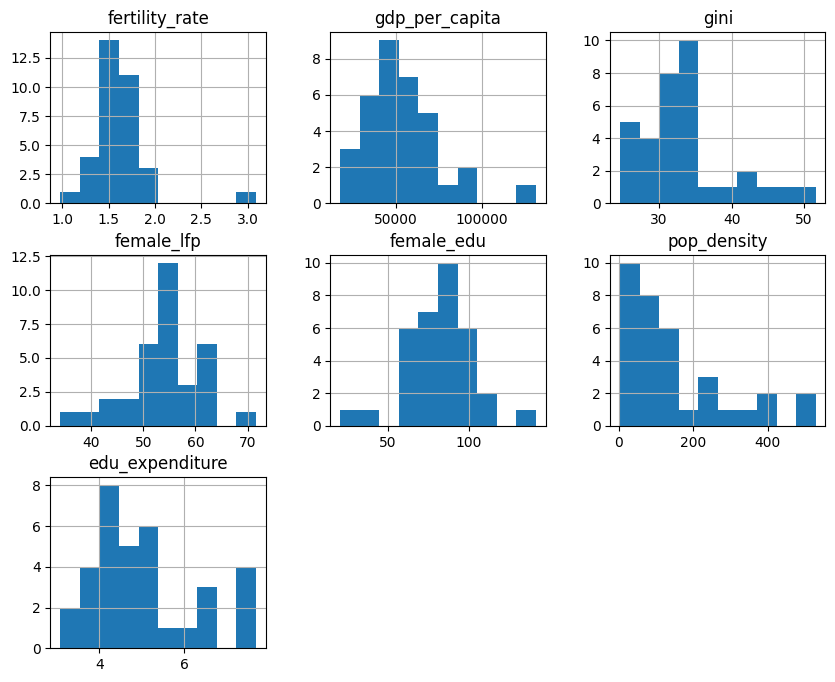

In [8]:
oecd_df.hist(figsize=(10,8))

### 相関分析

In [9]:
cols = ['fertility_rate', 'gdp_per_capita', 'gini', 'female_lfp', 
        'female_edu', 'pop_density', 'edu_expenditure']

oecd_df[cols].corr()['fertility_rate']

fertility_rate     1.000000
gdp_per_capita    -0.155414
gini               0.269387
female_lfp         0.087914
female_edu        -0.132579
pop_density        0.025182
edu_expenditure    0.274957
Name: fertility_rate, dtype: float64

出生率は、
* ジニ係数(0.27)、教育への政府支出(0.27)と正の相関
* GDP(-0.16)、女性の大学進学率(-0.13)と負の相関
* 女性の労働参加率(0.09)、人口密度(0.03)とはほぼ無相関

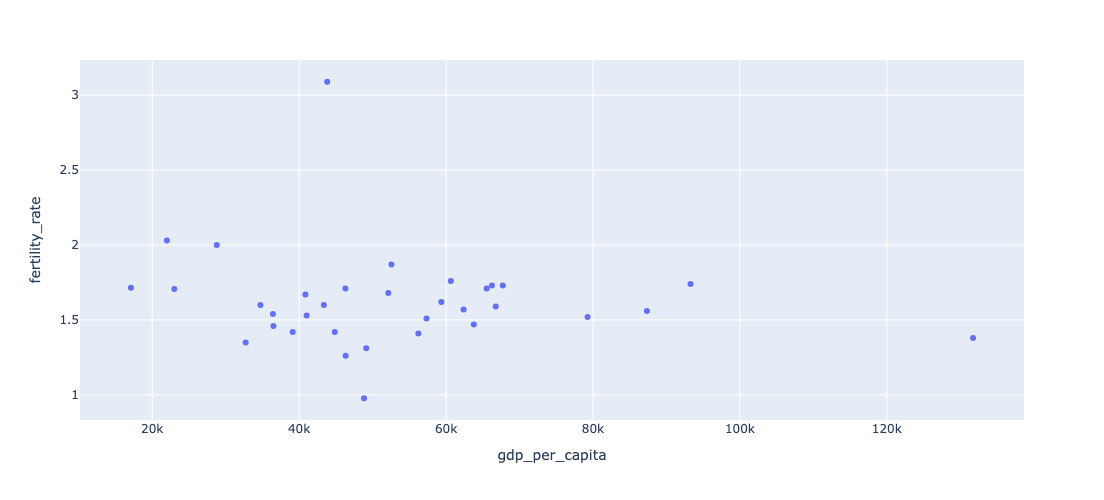

In [10]:
px.scatter(oecd_df, x='gdp_per_capita', y='fertility_rate', 
           hover_name='Country Name', 
           width=700, height=500)

→ イスラエル（出生率:3.1）とルクセンブルク（GDP:132k）が外れ値の可能性あり

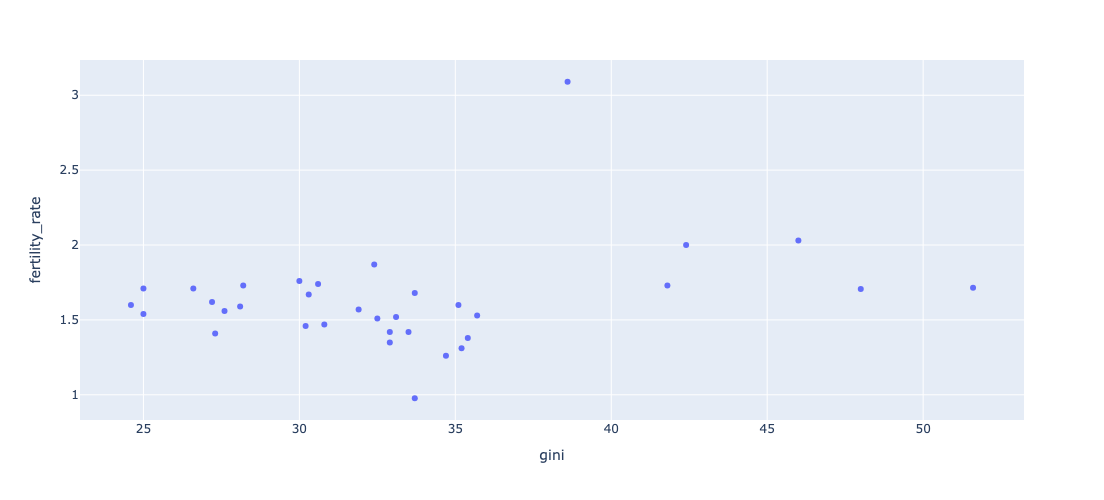

In [11]:
px.scatter(oecd_df, x='gini', y='fertility_rate', 
           hover_name='Country Name', 
           width=700, height=500)

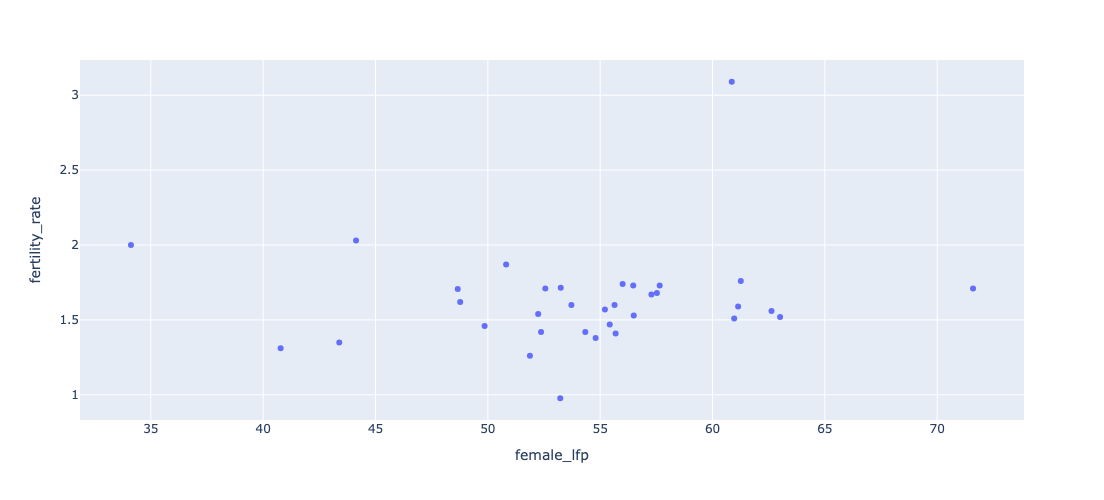

In [12]:
px.scatter(oecd_df, x='female_lfp', y='fertility_rate', 
           hover_name='Country Name', 
           width=700, height=500)

トルコ(34.1)とアイスランド(71.6)が外れ値の可能性あり

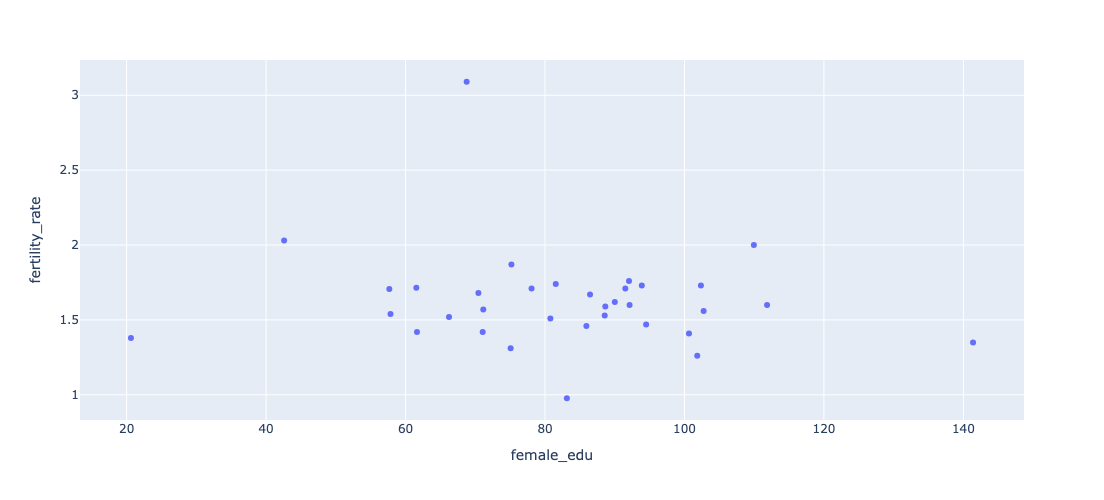

In [13]:
px.scatter(oecd_df, x='female_edu', y='fertility_rate', 
           hover_name='Country Name', 
           width=700, height=500)

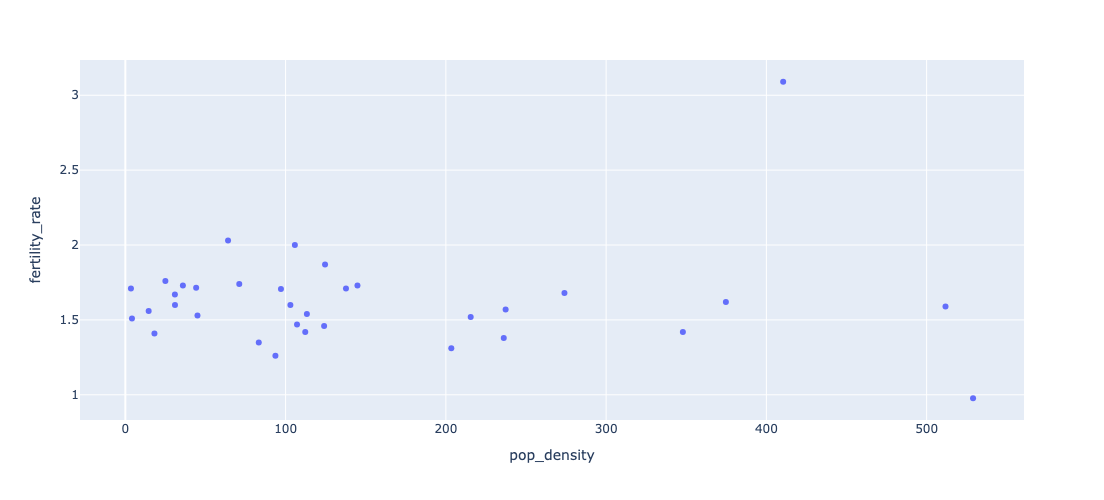

In [14]:
px.scatter(oecd_df, x='pop_density', y='fertility_rate', 
           hover_name='Country Name', 
           width=700, height=500)

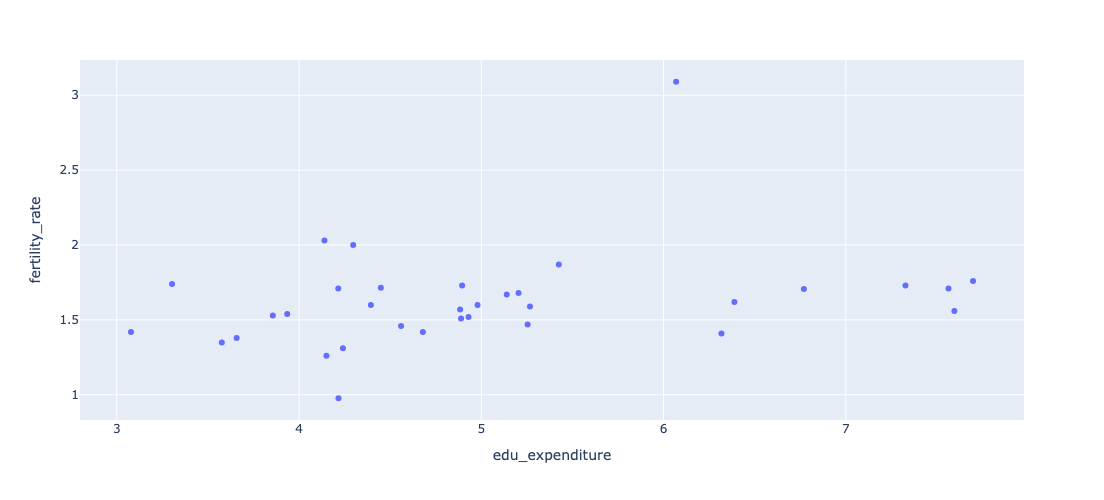

In [15]:
px.scatter(oecd_df, x='edu_expenditure', y='fertility_rate', 
           hover_name='Country Name', 
           width=700, height=500)

In [16]:
oecd_df[['Country Name', 'fertility_rate']].sort_values(by='fertility_rate', ascending=False)

,Country Name,fertility_rate
17,Israel,3.0900
24,Mexico,2.0300
32,Turkiye,2.0000
12,France,1.8700
31,Sweden,1.7600
15,Ireland,1.7400
8,Denmark,1.7300
33,United States,1.7295
4,Colombia,1.7150
6,Czechia,1.7100


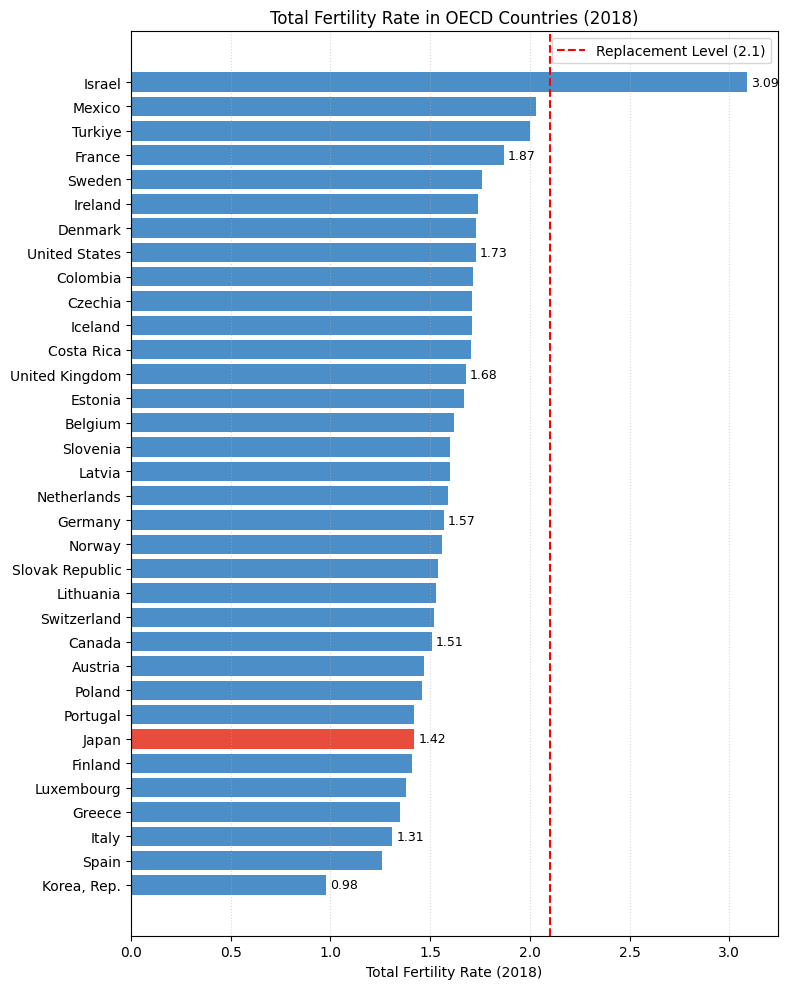

In [17]:
# ============================================================
# OECD加盟国の出生率・棒グラフ
# ============================================================

highlight = ['Japan', 'Korea, Rep.', 'Israel', 
             'Canada', 'France', 'Germany', 'Italy', 
             'United Kingdom', 'United States']

df_sorted = oecd_df[['Country Name', 'fertility_rate']].sort_values(by='fertility_rate', ascending=True)

colors = ['#E84C3D' if c == 'Japan' else '#4B8EC8' for c in df_sorted['Country Name']]

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(df_sorted['Country Name'], df_sorted['fertility_rate'], color=colors)

for i, (_, row) in enumerate(df_sorted.iterrows()):
    if row['Country Name'] in highlight:
        ax.text(row['fertility_rate'] + 0.02, i, 
                f"{row['fertility_rate']:.2f}", 
                va='center', fontsize=9)

ax.set_xlabel('Total Fertility Rate (2018)')
ax.set_title('Total Fertility Rate in OECD Countries (2018)')
ax.grid(axis='x', linestyle=':', alpha=0.5)
ax.axvline(x=2.1, color='red', linestyle='--', linewidth=1.5, label='Replacement Level (2.1)')
ax.legend()
plt.tight_layout()
plt.savefig('../images/oecd_fertility_rate.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
no_isr_df = oecd_df[oecd_df['Country Code'] != 'ISR']

# colsは上のセルで定義済み
print('イスラエルあり:')
print(oecd_df[cols].corr()['fertility_rate'])
print()
print('イスラエルなし:')
print(no_isr_df[cols].corr()['fertility_rate'])

イスラエルあり:
fertility_rate     1.000000
gdp_per_capita    -0.155414
gini               0.269387
female_lfp         0.087914
female_edu        -0.132579
pop_density        0.025182
edu_expenditure    0.274957
Name: fertility_rate, dtype: float64

イスラエルなし:
fertility_rate     1.000000
gdp_per_capita    -0.160459
gini               0.253482
female_lfp        -0.070890
female_edu        -0.076098
pop_density       -0.389869
edu_expenditure    0.261885
Name: fertility_rate, dtype: float64


イスラエルあり：人口密度と出生率はほぼ無相関（r = 0.03）
イスラエルなし：中程度の負の相関（r = -0.39）

* イスラエルは宗教・文化的要因による例外的な高出生率国であり、
  この1カ国が人口密度と出生率の関係を隠蔽していた
* イスラエルを除外すると「都市化・高密度化が出生率低下と関連する」
  という仮説と整合的な結果が得られる

## 日本の時系列分析

In [19]:
def extract_japan_timeseries(file_path, value_name):
    # 読み込み
    df = pd.read_csv(file_path, skiprows=4)

    # 日本だけ抽出
    japan = df[df['Country Name'] == 'Japan']

    # 年列
    years = [str(year) for year in range(1960, 2025)]

    # 縦持ち変換
    ts = japan[years].T.reset_index()

    # 列名
    ts.columns = ['year', value_name]

    # 型変換
    ts['year'] = ts['year'].astype(int)
    ts[value_name] = pd.to_numeric(ts[value_name], errors='coerce')   # errors='coerce': 数値に変換できない値をNaNに置き換えて処理を続行

    return ts

In [20]:
fertility = extract_japan_timeseries('../data/fertility_rate.csv', 'fertility_rate')

gdp = extract_japan_timeseries('../data/gdp_per_capita.csv', 'gdp_per_capita')
gini = extract_japan_timeseries('../data/gini.csv', 'gini')
female_lfp = extract_japan_timeseries('../data/female_lfp.csv', 'female_lfp')
female_edu = extract_japan_timeseries('../data/female_edu.csv', 'female_edu')
pop_density = extract_japan_timeseries('../data/population_density.csv', 'pop_density')
edu_exp = extract_japan_timeseries('../data/education_expenditure.csv', 'edu_expenditure')

# mergeはYearをキーに順番につなぐ
dfs = [gdp, gini, female_lfp, female_edu, pop_density, edu_exp]

japan_df = fertility.copy()
for d in dfs:
    japan_df = pd.merge(japan_df, d, on='year', how='left')

japan_df

,year,fertility_rate,gdp_per_capita,gini,female_lfp,female_edu,pop_density,edu_expenditure
0,1960,2.00,NaN,NaN,NaN,NaN,NaN,NaN
1,1961,1.96,NaN,NaN,NaN,NaN,256.490319,NaN
2,1962,1.98,NaN,NaN,NaN,NaN,258.884647,NaN
3,1963,2.00,NaN,NaN,NaN,NaN,261.521680,NaN
4,1964,2.05,NaN,NaN,NaN,NaN,264.256886,NaN
...,...,...,...,...,...,...,...,...
60,2020,1.33,42992.479637,32.3,53.090,61.758369,346.395062,3.30629
61,2021,1.30,44355.348716,NaN,53.460,61.440338,344.805468,3.33664
62,2022,1.26,44972.343836,NaN,54.173,62.414799,343.278433,NaN
63,2023,1.20,45858.659513,NaN,54.847,63.629330,341.544557,NaN


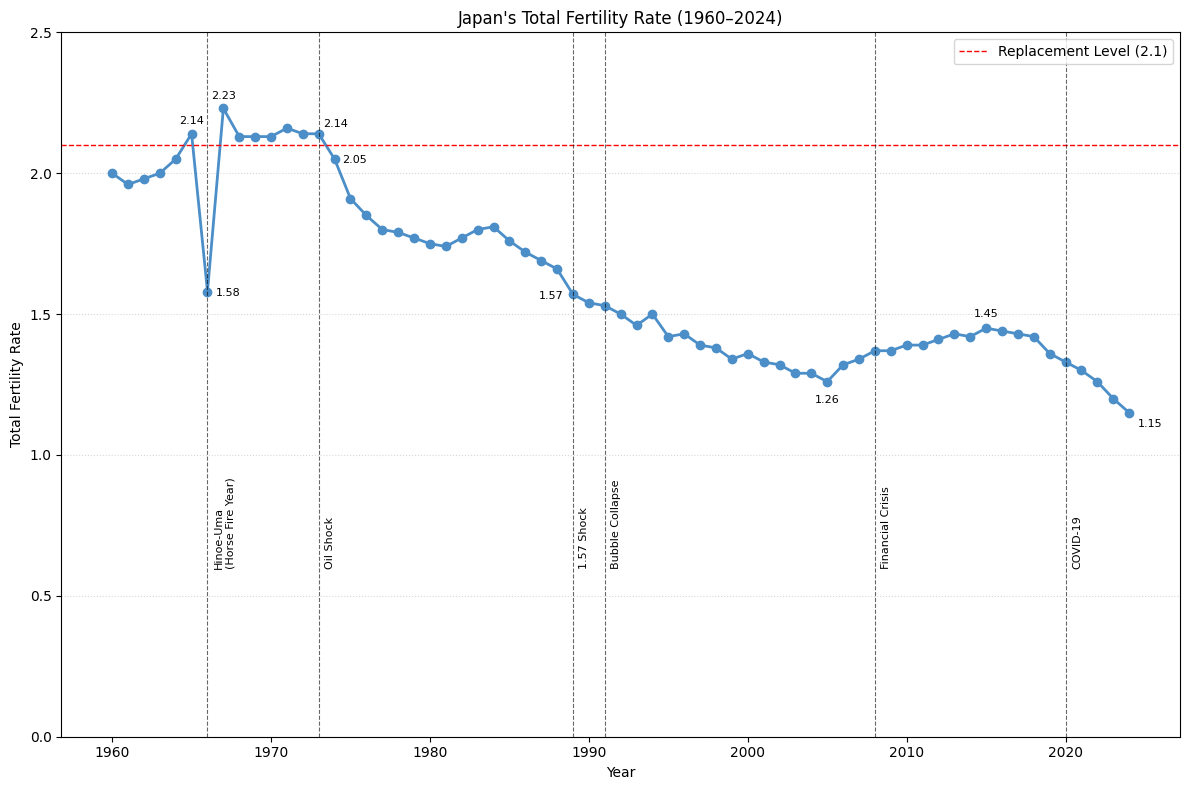

In [21]:
# ============================================================
# 日本の出生率・折れ線グラフ
# ============================================================

fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(japan_df['year'], japan_df['fertility_rate'], marker='o', color='#4B8EC8', linewidth=2)

# 主要な年の出生率を表示
label_years = [1965, 1966, 1967, 1973, 1974, 1989, 2005, 2015, 2024]
annotation_xy = {
    1965: (0, 7), 
    1966: (15, -3), 
    1967: (0, 7), 
    1973: (12, 5), 
    1974: (14, -3), 
    1989: (-16, -3), 
    2005: (0, -15), 
    2015: (0, 8), 
    2024: (15, -10), 
}
for year in label_years:
    val = japan_df.loc[japan_df['year'] == year, 'fertility_rate'].values
    if len(val) > 0:
        ax.annotate(f'{val[0]:.2f}',
                    xy=(year, val[0]),
                    xytext=annotation_xy[year],
                    textcoords='offset points',
                    fontsize=8, color='black',
                    ha='center')

# 人口維持水準ライン
ax.axhline(y=2.1, color='red', linestyle='--', linewidth=1, label='Replacement Level (2.1)')

# 主要イベントのアノテーション
events = {
    1966: 'Hinoe-Uma\n(Horse Fire Year)',
    1973: 'Oil Shock', 
    1989: '1.57 Shock',
    1991: 'Bubble Collapse',
    2008: 'Financial Crisis',
    2020: 'COVID-19'
}
for year, label in events.items():
    val = japan_df.loc[japan_df['year'] == year, 'fertility_rate'].values
    if len(val) > 0:
        ax.axvline(x=year, color='black', linestyle='--', linewidth=0.8, alpha=0.6)
        ax.text(year + 0.4, ax.get_ylim()[0] - 0.5, label,
                fontsize=8, color='black', rotation=90, va='bottom')

ax.set_xlabel('Year')
ax.set_ylabel('Total Fertility Rate')
ax.set_title("Japan's Total Fertility Rate (1960–2024)")
ax.legend()
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_axisbelow(True)

plt.ylim(0, 2.5)
plt.tight_layout()
plt.savefig('../images/japan_fertility_rate.png', dpi=150, bbox_inches='tight')
plt.show()

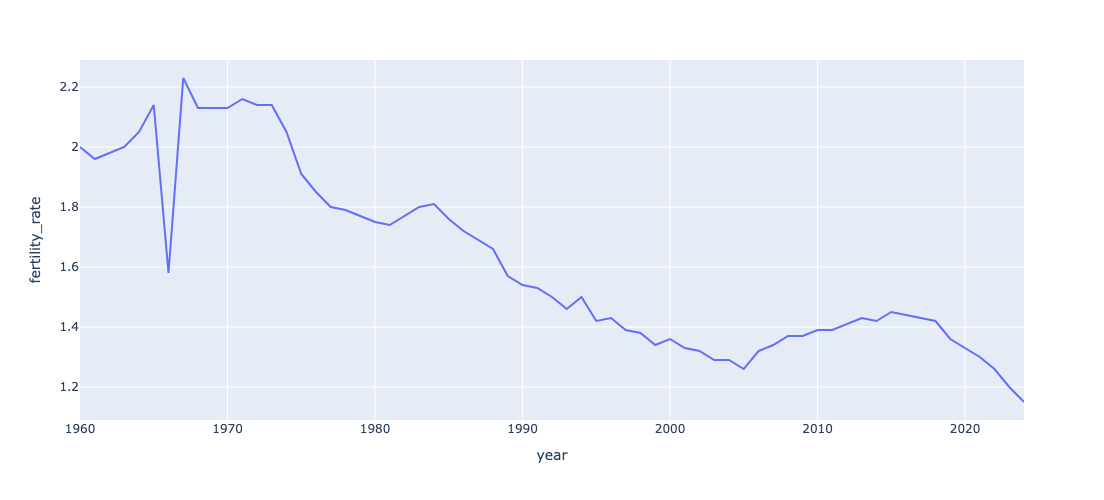

In [22]:
# 確認用（ポートフォリオには使用せず）
px.line(japan_df, x='year', y='fertility_rate', width=700, height=500)